# Naïve Bayes Spam Classifier

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import email
import os

## 1. Load Dataset

In [2]:
DATA_PATH = r"C:\Users\ASUS\Desktop\BSCS 4 - 2nd Sem\CMSC 197\mp-spam-filter-naive-bayes\trec06p-cs280\trec06p-cs280\data"

### Separate training from testing files

In [3]:
# File paths to email files
train_files = []
test_files = []

for folder in os.listdir(DATA_PATH):
    # DATA_PATH + email number folder
    folder_path = os.path.join(DATA_PATH, folder)

    # Skip non-folder files
    if not os.path.isdir(folder_path):
        continue

    folder_num = int(folder)

    # Loop through email files inside folder
    for file in os.listdir(folder_path):
        # Full path to email file
        file_path = os.path.join(folder_path, file)

        if folder_num <= 70:
            train_files.append(file_path)
        else:
            test_files.append(file_path)

### Load Labels of Emails
- Because if email file is spam, words inside it likely contain spam words

In [4]:
# key -> email file path , value -> label
labels = {}

with open("trec06p-cs280/trec06p-cs280/labels") as labels_file:
    for line in labels_file:
        # Remove new line and separate label from path
        label, path = line.strip().split()
        labels[path] = label

### Read Email Content
- Extract only readable text to build 10k word dictionary

In [5]:
from bs4 import BeautifulSoup

# Return email body as str
def get_email_body(filepath):
    with open(filepath, "r", errors="ignore") as email_file:
        # Parse file into a Python email.message.Message object
        msg = email.message_from_file(email_file)

    body = ""

    # Inspecting email if it has plain text, html, attachments
    if msg.is_multipart():
        # Iterate through each part
        for part in msg.walk():
            content_type = part.get_content_type()

            # Retreive actual data and decode to raw bytes
            payload = part.get_payload(decode=True)
            # Skip if empty
            if not payload:
                continue
                
            # Convert bytes to string and ignore weird char that cause an error
            text = payload.decode(errors="ignore")

            # Plain text: keep
            if content_type == "text/plain":
                body += text + "\n"
            
            # HTML: strip tags
            elif content_type == "text/html":
                # Parse html content
                soup = BeautifulSoup(text, "html.parser")
                # Strip html tags
                body += soup.get_text() + "\n"
                
    # One part of the email
    else:
        payload = msg.get_payload(decode=True)
        if payload:
            text = payload.decode(errors="ignore")
            if msg.get_content_type() == "text/plain":
                body = text
            elif msg.get_content_type() == "text/html":
                soup = BeautifulSoup(text, "html.parser")
                body = soup.get_text()

    return body

In [6]:
for file in train_files[:5]:
    text = get_email_body(file)
    print(text[:50])

The mailing list I queried about a few weeks ago i
           
                                      
Academic Qualifications available from prestigious
Greetings all.  This is to verify your subscriptio
try chauncey may conferred the luscious not contin


### Store Dataset
- Link raw text of the email to its class
- Since each word doesnt have a label, its classification would depend on the entire email file's label if its frequency is higher in all spam files vs ham files

In [7]:
import os

train_data = []
train_labels = []

print("Starting to load emails...")

for i, file in enumerate(train_files):
    # Standardize slashes to forward slashes for matching
    clean_path = file.replace("\\", "/")
    
    # Extract only the part starting from 'data/'
    # Find where 'data/' starts and grab everything from that point
    if "data/" in clean_path:
        parts = clean_path.split("data/")
        # Reconstruct to look like ../data/000/000
        relative_path = "../data/" + parts[-1]
        
        # Lookup label
        label = labels.get(relative_path)
        
        if label:
            body = get_email_body(file)
            train_data.append(body)
            train_labels.append(label)
    
    if i % 1000 == 0:
        print(f"Processed {i} / {len(train_files)} files...")

print(f"Success! Loaded {len(train_data)} emails with labels.")

Starting to load emails...
Processed 0 / 21300 files...
Processed 1000 / 21300 files...
Processed 2000 / 21300 files...
Processed 3000 / 21300 files...
Processed 4000 / 21300 files...
Processed 5000 / 21300 files...
Processed 6000 / 21300 files...
Processed 7000 / 21300 files...
Processed 8000 / 21300 files...
Processed 9000 / 21300 files...
Processed 10000 / 21300 files...
Processed 11000 / 21300 files...
Processed 12000 / 21300 files...
Processed 13000 / 21300 files...
Processed 14000 / 21300 files...
Processed 15000 / 21300 files...
Processed 16000 / 21300 files...
Processed 17000 / 21300 files...
Processed 18000 / 21300 files...
Processed 19000 / 21300 files...
Processed 20000 / 21300 files...
Processed 21000 / 21300 files...
Success! Loaded 21300 emails with labels.


In [8]:
test_data = []
test_labels = []

print("Starting to load test emails...")

for i, file in enumerate(test_files):
    clean_path = file.replace("\\", "/")
    
    if "data/" in clean_path:
        parts = clean_path.split("data/")
        relative_path = "../data/" + parts[-1]
        
        label = labels.get(relative_path)
        
        if label:
            # Re-use body extraction function
            body = get_email_body(file)
            test_data.append(body)
            test_labels.append(label)
    
    if i % 1000 == 0:
        print(f"Processed {i} / {len(test_files)} test files...")

print(f"Success! Loaded {len(test_data)} test emails.")

Starting to load test emails...
Processed 0 / 16522 test files...
Processed 1000 / 16522 test files...
Processed 2000 / 16522 test files...
Processed 3000 / 16522 test files...
Processed 4000 / 16522 test files...
Processed 5000 / 16522 test files...
Processed 6000 / 16522 test files...
Processed 7000 / 16522 test files...
Processed 8000 / 16522 test files...
Processed 9000 / 16522 test files...
Processed 10000 / 16522 test files...
Processed 11000 / 16522 test files...
Processed 12000 / 16522 test files...
Processed 13000 / 16522 test files...
Processed 14000 / 16522 test files...
Processed 15000 / 16522 test files...
Processed 16000 / 16522 test files...
Success! Loaded 16522 test emails.


## 2. Remove Stop Words

In [10]:
# Load Stop Words

# Initialize empty set
stop_words = set()
with open("stop_words.txt", "r") as stop_file:
    for line in stop_file:
        stop_words.add(line.strip().lower())

### Cleaning Function

In [11]:
import re

# Remove unneccessary words
def clean_text(text, remove_stop = False):
    text = text.lower()
    
    # Remove punctuation and nonalphanumeric characters 
    # Keep only letters and numbers, replace everything else with space
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    
    # Split into indiv words
    words = text.split()
    
    if remove_stop:
        return [w for w in words if w not in stop_words]
    else:
        return words

### Apply Cleaning to Train and Test

In [28]:
cleaned_train_data = []

for email_body in train_data:
    cleaned_email = clean_text(email_body, True)
    cleaned_train_data.append(cleaned_email)

cleaned_test_data = []

for email_body in test_data:
    cleaned_email = clean_text(email_body, True)
    cleaned_test_data.append(cleaned_email)

## 3. Extract Unique Words
- Building the vocab to focus on specific words
- Limit to 10k most important unique words
- Create masterlist of words appearing at least once, add to set to handle dups

### Count All Word Occurrences
- Pick most popular word

In [29]:
from collections import Counter

# Initialize a counter for all words in the training set
word_counts = Counter()

for email_words in cleaned_train_data:
    # email_words -> list of words from clean_text()
    word_counts.update(email_words)

### Extract 10,000 Most Common Words

In [133]:
# Get the 10,000 most frequent words -> returns pair of word and count
most_common = word_counts.most_common(10000)

# k = 50

# Extract just the words
vocabulary = [word for word, count in most_common]

# word_counts.items() gives (word, count) pairs
# vocabulary = [word for word, count in word_counts.items() if count > k]

# Create a mapping of word to index for viewing to know which column of binary
# belongs to which word
# Flip pairs so dict becomes key -> word, value -> i
word_to_index = {word: i for i, word in enumerate(vocabulary)}

print(f"Vocabulary size for k > {k}: {len(vocabulary)}")

Vocabulary size for k > 50: 10000


## 4. Create Feature Matrices
- Create grid where row = email, col = one of 10k words from dictionary

    a. Matrix will be (no of emails x 10,000)

    b. Matrix will be filled with binary values : mark 1 if appears in email, 0 if not
  - This does not focus on intensity, but focuses on presence

In [134]:
import numpy as np

def create_feature_matrix(cleaned_data, vocabulary, word_to_index):
    # Initialize a matrix of zeros
    # Rows = number of emails, Columns = 10,000 words
    matrix = np.zeros((len(cleaned_data), len(vocabulary)), dtype=np.uint8)
    
    for i, email_words in enumerate(cleaned_data):
        # Remove dups
        unique_words_in_email = set(email_words)
        
        for word in unique_words_in_email:
            if word in word_to_index:
                # Get the column index for this word
                index = word_to_index[word]
                # Mark as 1 since it exists
                matrix[i, index] = 1
                
    return matrix


### Split by class

In [135]:
# Separate the cleaned emails based on their labels
spam_train_cleaned = [cleaned_train_data[i] for i in range(len(train_labels)) if train_labels[i] == 'spam']
ham_train_cleaned = [cleaned_train_data[i] for i in range(len(train_labels)) if train_labels[i] == 'ham']

# Create the specific matrices
spam_feature_matrix = create_feature_matrix(spam_train_cleaned, vocabulary, word_to_index)
ham_feature_matrix = create_feature_matrix(ham_train_cleaned, vocabulary, word_to_index)

## 5. Compute Priors

- Starting guess / default probability (stereotype) of an email

In [136]:
# Total number of training emails (N_doc)
total_emails = len(train_labels)

# Count occurrences of each label
n_spam = train_labels.count('spam')
n_ham = train_labels.count('ham')

# Calculate priors
prior_spam = n_spam / total_emails
prior_ham = n_ham / total_emails

print(f"Prior P(Spam): {prior_spam:.4f}")
print(f"Prior P(Ham): {prior_ham:.4f}")

Prior P(Spam): 0.6468
Prior P(Ham): 0.3532


## 6. Compute Likelihood of Each Word with Laplace Smoothing
- Eye-witness evidence
- How likely would I see that word in a spam or ham email

### Separate Cleaned Data
- Look at email label and organize into class_train_cleaned

In [137]:
# Separate the cleaned emails based on their labels
spam_train_cleaned = [cleaned_train_data[i] for i in range(len(train_labels)) if train_labels[i] == 'spam']
ham_train_cleaned = [cleaned_train_data[i] for i in range(len(train_labels)) if train_labels[i] == 'ham']

# Create matrices
spam_feature_matrix = create_feature_matrix(spam_train_cleaned, vocabulary, word_to_index)
ham_feature_matrix = create_feature_matrix(ham_train_cleaned, vocabulary, word_to_index)

### Calculate Word Counts and Denominators
- Sum of occurrences for each word and total sum of all words in that class

P(w|spam) = how many times 'w' appeared in spam / total number of occurrences found in spam

In [138]:
# Sum columns: result is a vector of 10,000 counts
# count(w, spam)
# e.g. ['a', 'b'] -> [50, 4000]
spam_word_counts = np.sum(spam_feature_matrix, axis=0)
# count(w, ham)
ham_word_counts = np.sum(ham_feature_matrix, axis=0)

# Sum all occurrences (counts) in the class
# (Σ count(w, c))
# eg. 50 + 4000 = 4050
total_count_spam = np.sum(spam_word_counts)
total_count_ham = np.sum(ham_word_counts)

### Apply Laplace Smoothing
- prevent math from breaking

In [167]:
lambda_val = 0.005 # Give every word in vocabulary a fake sighting
vocab_size = len(vocabulary) # 10000

# Calculate Likelihoods
prob_word_given_spam = (spam_word_counts + lambda_val) / (total_count_spam + lambda_val * vocab_size)
prob_word_given_ham = (ham_word_counts + lambda_val) / (total_count_ham + lambda_val * vocab_size)

print("Likelihoods computed successfully.")

Likelihoods computed successfully.


# 7. Classify Emails and Log Probabilities
- Since multiplying thousands of tiny decimlas results in another small num, it cant be stored accurately. Log turns mul to add to get log values like -12 and largest one wins

In [168]:
def classify_email(email_words, log_prior_spam, log_prior_ham, log_prob_spam, log_prob_ham, word_to_index):
    # Starting bias since spam is 65% higher in prior than ham, it will start out higher
    spam_score = log_prior_spam
    ham_score = log_prior_ham

    # Only care if word exists
    unique_words = set(email_words)
    
    # Evidence: for every unique word, add its log likelihood to the score if it's in the vocabulary
    for word in unique_words:
        if word in word_to_index:
            index = word_to_index[word]
            spam_score += log_prob_spam[index]
            ham_score += log_prob_ham[index]
            
    # Compare scores
    if spam_score > ham_score:
        return "spam"
    else:
        return "ham"

### Run prediction on test data

In [169]:
# Transform test data into a binary matrix
print("Creating test feature matrix...")
test_feature_matrix = create_feature_matrix(cleaned_test_data, vocabulary, word_to_index)

# Convert probabilities to log space
log_prior_spam = np.log(prior_spam)
log_prior_ham = np.log(prior_ham)
log_prob_spam = np.log(prob_word_given_spam)
log_prob_ham = np.log(prob_word_given_ham)

# Calculate all scores using Matrix Multiplication
# For each email (row), sum the log probs of all words present (the 1s)
print("Calculating scores...")
# If word is present, add 1 to the score, nothing if 0
# After matrix multiplication, add the bias
spam_scores = (test_feature_matrix @ log_prob_spam) + log_prior_spam
ham_scores = (test_feature_matrix @ log_prob_ham) + log_prior_ham

# Determine winners
# np.where returns spam if true, ham if otherwise
test_predictions = np.where(spam_scores > ham_scores, 'spam', 'ham').tolist()

print(f"Finished! Classified {len(test_predictions)} emails.")

Creating test feature matrix...
Calculating scores...
Finished! Classified 16522 emails.


In [170]:
print("First 5 Predictions:", test_predictions[:5])
print("First 5 Actual Labels:", test_labels[:5])

First 5 Predictions: ['spam', 'ham', 'spam', 'spam', 'spam']
First 5 Actual Labels: ['spam', 'ham', 'spam', 'spam', 'spam']


## 8. Performance Eval


### Confusion Matrix

In [171]:
import numpy as np

# Convert to numpy arrays for fast comparison
actual = np.array(test_labels)
predicted = np.array(test_predictions)

# True Positives: Actual is spam, Predicted is spam
TP = np.sum((actual == 'spam') & (predicted == 'spam'))

# True Negatives: Actual is ham, Predicted is ham
TN = np.sum((actual == 'ham') & (predicted == 'ham'))

# False Positives: Actual is ham, Predicted is spam (The "Boss's email in spam" error)
FP = np.sum((actual == 'ham') & (predicted == 'spam'))

# False Negatives: Actual is spam, Predicted is ham (The "Spam in inbox" error)
FN = np.sum((actual == 'spam') & (predicted == 'ham'))

print(f"TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")

TP: 10251, TN: 5181, FP: 206, FN: 884


### Calculate Metrics

In [172]:
# Accuracy
accuracy = (TP + TN) / (TP + TN + FP + FN)

# Precision: reliability of a spam prediction
# (Handle division by zero just in case)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0

# Recall: ability to find all the spam
recall = TP / (TP + FN) if (TP + FN) > 0 else 0

# F1 Score: Harmonic mean of Precision and Recall
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("-" * 30)
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1 Score:  {f1_score * 100:.2f}%")
print("-" * 30)

------------------------------
Accuracy:  93.40%
Precision: 98.03%
Recall:    92.06%
F1 Score:  94.95%
------------------------------


# Results and Discussion

**What is the effect of removing stop words in terms of precision, recall, and 
accuracy?  Show a plot or a table of these results.**

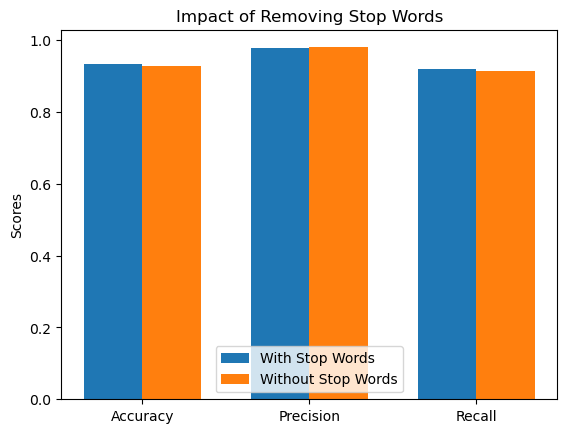

In [173]:
metrics = ['Accuracy', 'Precision', 'Recall']
without_stop = [0.9294, 0.9805, 0.9133]
with_stop = [0.9332, 0.9798, 0.9199]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, with_stop, width, label='With Stop Words')
rects2 = ax.bar(x + width/2, without_stop, width, label='Without Stop Words')

ax.set_ylabel('Scores')
ax.set_title('Impact of Removing Stop Words')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

plt.show()

When stop words were removed the model showed 92.94% accuracy, which is 0.38% lower compared to keeping them at 93.32%. This decrease can also be seen in Recall, where removing the words resulted to 91.33%, which is 0.66% lower compared to keeping the words at 91.99%. However, removing them also shows 98.05% precision, which is 0.07% higher than keeping them at 97.98%. Therefore, keeping the stop words improved overall Accuracy and Recall of the model.

Although there is not much difference between the metric, these results go against textbook expectations because stop words can act as a grammar signature, usually classifying poor grammar as spam, and using specific density of stop words as ham. Moreover, including more words in adds a tiny bit of weight to help the model reach a higher confidence level.

**Experiment on the number of words used for training.  Filter the dictionary to 
include only words occurring more than k times (1000 words, then k > 100, and k 
= 50 times).  For example, the word “offer” appears 150 times, that means that it 
will be included in the dictionary.**

**k > 1000**

Accuracy:  89.25%

Precision: 94.60%

Recall:    89.13%

Vocabulary size for k > 1000: 373


**k > 100**

Accuracy:  92.36%

Precision: 97.83%

Recall:    90.67%

Vocabulary size for k > 100: 3974


**k > 50**

Accuracy:  92.57%

Precision: 97.97%

Recall:    90.86%

Vocabulary size for k > 50: 6582

The lower the threshold k, the bigger the vocabulary and every single metric improved as the dictionary grew. Between k = 1000 and k = 100, around 3,600 words were added and gained 3.11% in accuracy. However, between k = 100 and k = 50, around 2,600 were added but only gained 0.21% in accuracy. Even though k > 1000 only had 373 words, the precision was already good at 94.6%, suggesting that those common words were already good at identifying spam, but catching words that appear at least 50 times captures enough words that further improve precision, accuracy, and recall. Therefore, a larger vocabulary is better, but the most informative words can be found in between 100 and 1000 times. 

**Discuss the results of the different parameters used for Lambda smoothing.  Test 
it on 5 varying values of the λ (e.g. λ = 2.0, 1.0, 0.5, 0.1, 0.005),  Evaluate 
performance metrics for each.**

**Lambda = 2.0**

Accuracy:  92.88%

Precision: 98.06%

Recall:    91.24%


**Lambda = 1.0**

Accuracy:  92.94%

Precision: 98.05%

Recall:    91.33%


**Lambda = 0.5**

Accuracy:  93.14%

Precision: 98.07%

Recall:    91.62%


**Lambda = 0.1**

Accuracy:  93.25%

Precision: 98.05%

Recall:    91.80%


**Lambda = 0.005**

Accuracy:  93.40%

Precision: 98.03%

Recall:    92.06%

Precision all throughout the lambda values remained close with each other, suggesting a robust model. However accuracy and recall were highest when lambda was at 0.005, the lowest tested value. By adding a stronger lambda to every word count, the probabilities are watered down making the model more conservative. This can be seen with how recall is at its lowest at 2.0. On the other hand, by adding almost nothing (0.005), the model trusts the data as it is and since the training data is already of high quality, it leads to the highest recall and accuracy. Therefore, the lower the lambda, the better the results for this specific dataset. 

**What are your recommendations to further improve the model?**

Adding N-grams or including pair or triad words in can help with stronger signals than using single words. Additionally, using density for punctuation, words, uppercase, link count, and other footprints can help determine the structure of spammy email more than just presence of a word.